# Practical: Uncertainty in ODEs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import solve as lin_solve

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
np.random.seed(42)

# RK4 solver from PRA7 — scalar ODEs
def rk4(f, y0, t0, t_end, h=0.05):
    t_arr, y_arr = [t0], [y0]
    t, y = t0, y0
    while t < t_end - 1e-10:
        k1 = f(t,        y)
        k2 = f(t + h/2,  y + h/2 * k1)
        k3 = f(t + h/2,  y + h/2 * k2)
        k4 = f(t + h,    y + h   * k3)
        y  = y + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)
        t += h
        t_arr.append(t)
        y_arr.append(y)
    return np.array(t_arr), np.array(y_arr)

# Euler solver from PRA7
def euler(f, y0, t0, t_end, h):
    t_arr, y_arr = [t0], [y0]
    t, y = t0, y0
    while t < t_end - 1e-10:
        y = y + h * f(t, y)
        t = t + h
        t_arr.append(t)
        y_arr.append(y)
    return np.array(t_arr), np.array(y_arr)

In PRA7, every run started from exact inputs. In the real world, inputs always carry some error — in the initial condition, in a model parameter, or both. This practical asks: what happens to that error as the system evolves? Five questions, five different perspectives on the same general problem.

---

## Q1 — Sensitivity to Initial Conditions: "How bad can a small mistake get?"

Consider two ODEs, both defined on $t \in [0, 8]$ with $y(0) = 1$:

$$\text{System A:} \quad \frac{dy}{dt} = -2y \qquad \text{System B:} \quad \frac{dy}{dt} = +0.5\,y$$

The cell below plots the nominal trajectory for each so you know what you are working with before making predictions.

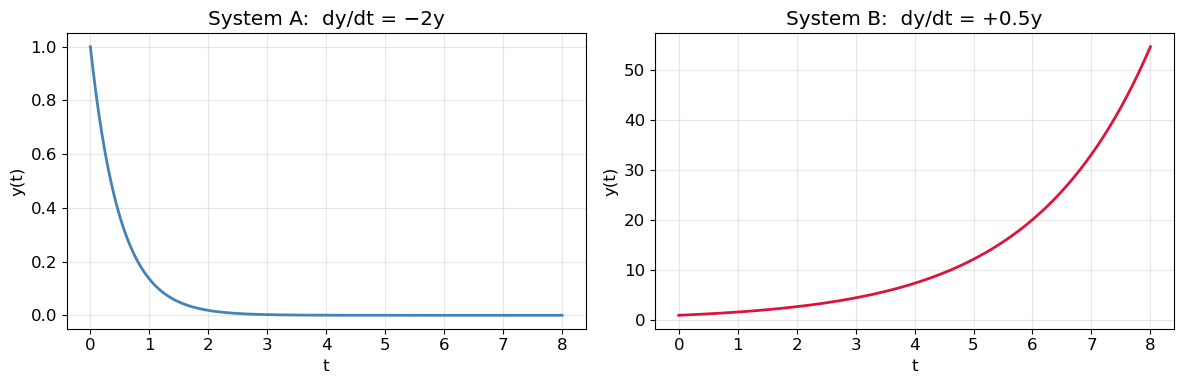

In [2]:
t_end_q1 = 8.0
y0_q1    = 1.0

sysA = lambda t, y: -2.0 * y
sysB = lambda t, y:  0.5 * y

t_A, y_A = rk4(sysA, y0_q1, 0, t_end_q1)
t_B, y_B = rk4(sysB, y0_q1, 0, t_end_q1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_A, y_A, 'steelblue', lw=2)
axes[0].set_title('System A:  dy/dt = −2y')
axes[1].plot(t_B, y_B, 'crimson',   lw=2)
axes[1].set_title('System B:  dy/dt = +0.5y')
for ax in axes:
    ax.set_xlabel('t')
    ax.set_ylabel('y(t)')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**a.** Before writing any code, predict for each system: will the gap $|y(t) - y_{\varepsilon}(t)|$ with $\varepsilon = 0.05$ grow, shrink, or stay constant over time? Write one sentence per system. Then plot the divergence for both systems on a single figure with a **logarithmic y-axis** and verify your prediction.

**b.** For **System B only**, repeat the divergence plot for $\varepsilon = 0.001$, $0.05$, and $0.5$ on the same log-scale axes. In one sentence, describe what the three curves have in common and what differs between them.

**c.** In one sentence per system: if you are solving an ODE in practice, what does the system's behavior tell you about how precisely you need to know $y_0$?

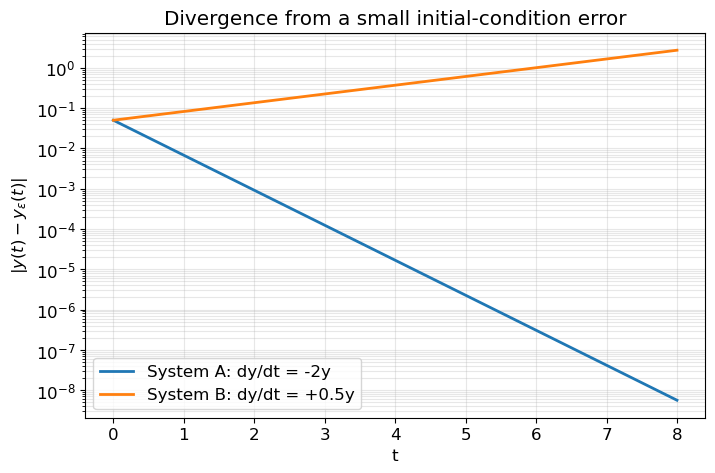

Initial gap in both systems: 0.05000
Final gap in System A at t=8.0: 5.62684e-09
Final gap in System B at t=8.0: 2.72991e+00


In [3]:
# Q1(a) — compare how an initial-condition perturbation evolves in each system
# We use the same epsilon in both cases, then plot the absolute gap on log-scale.

eps_q1 = 0.05

# Perturbed initial condition
y0_pert_q1 = y0_q1 + eps_q1

# Solve both nominal and perturbed problems
t_A_nom, y_A_nom = rk4(sysA, y0_q1, 0, t_end_q1)
t_A_pert, y_A_pert = rk4(sysA, y0_pert_q1, 0, t_end_q1)

t_B_nom, y_B_nom = rk4(sysB, y0_q1, 0, t_end_q1)
t_B_pert, y_B_pert = rk4(sysB, y0_pert_q1, 0, t_end_q1)

# Absolute divergence between the two trajectories
gap_A = np.abs(y_A_nom - y_A_pert)
gap_B = np.abs(y_B_nom - y_B_pert)

plt.figure(figsize=(8, 5))
plt.semilogy(t_A_nom, gap_A, lw=2, label='System A: dy/dt = -2y')
plt.semilogy(t_B_nom, gap_B, lw=2, label='System B: dy/dt = +0.5y')
plt.xlabel('t')
plt.ylabel(r'$|y(t) - y_\varepsilon(t)|$')
plt.title('Divergence from a small initial-condition error')
plt.grid(True, alpha=0.3, which='both')
plt.legend()
plt.show()

print(f"Initial gap in both systems: {eps_q1:.5f}")
print(f"Final gap in System A at t={t_end_q1}: {gap_A[-1]:.5e}")
print(f"Final gap in System B at t={t_end_q1}: {gap_B[-1]:.5e}")

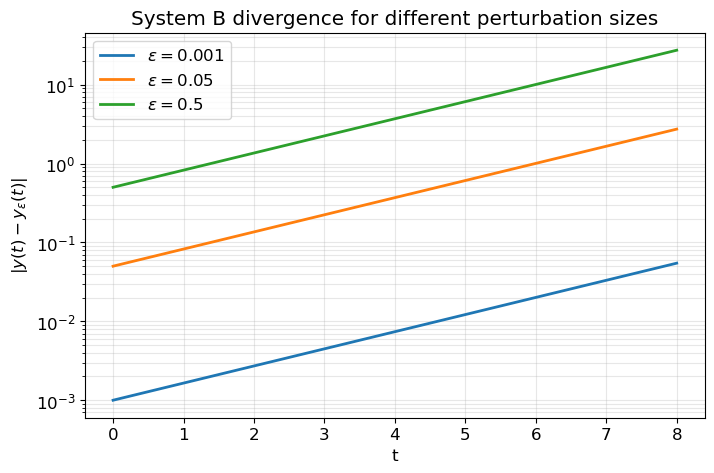

Mean ratio gap(0.05)/gap(0.001): 50.000000000000284
Mean ratio gap(0.5)/gap(0.05): 10.000000000000053
These ratios staying approximately constant means the curves are nearly parallel on the log plot.


In [4]:
# Q1(b) — repeat for System B with three different perturbation sizes
# On a log-scale, exponential growth should look like parallel curves if the
# growth rate is the same and only the initial gap changes.

eps_values_q1b = [0.001, 0.05, 0.5]

plt.figure(figsize=(8, 5))

for eps in eps_values_q1b:
  t_nom, y_nom = rk4(sysB, y0_q1, 0, t_end_q1)
  t_pert, y_pert = rk4(sysB, y0_q1 + eps, 0, t_end_q1)
  gap = np.abs(y_nom - y_pert)

  plt.semilogy(t_nom, gap, lw=2, label=fr'$\varepsilon = {eps}$')

plt.xlabel('t')
plt.ylabel(r'$|y(t) - y_\varepsilon(t)|$')
plt.title('System B divergence for different perturbation sizes')
plt.grid(True, alpha=0.3, which='both')
plt.legend()
plt.show()

# Check whether the ratios stay roughly constant over time.
t_nom, y_nom = rk4(sysB, y0_q1, 0, t_end_q1)
gaps = {}
for eps in eps_values_q1b:
  _, y_pert = rk4(sysB, y0_q1 + eps, 0, t_end_q1)
  gaps[eps] = np.abs(y_nom - y_pert)

ratio_1 = gaps[0.05] / gaps[0.001]
ratio_2 = gaps[0.5] / gaps[0.05]

print("Mean ratio gap(0.05)/gap(0.001):", np.mean(ratio_1))
print("Mean ratio gap(0.5)/gap(0.05):", np.mean(ratio_2))
print("These ratios staying approximately constant means the curves are nearly parallel on the log plot.")


**Answers — Q1**

**a.**  
For System A, the gap shrinks over time because both solutions decay exponentially toward zero, so the initial perturbation is damped out. $(e^{-2x})$ function
For System B, the gap grows over time because the same exponential factor that grows the solution also amplifies the initial perturbation. $(e^{0.5x})$ function

**b.**  
All three System B curves are approximately parallel lines meaning they share the same exponential growth rate, but they vary in the initial pertubation.

**c.**  
For System A, you do not need extremely precise knowledge of \(y_0\), because the system naturally suppresses small initial errors as time goes on.  
For System B, you need much more precise knowledge of \(y_0\), because even a small initial error is amplified exponentially and can become large later.


---

## Q2 — Competing Uncertainties: "Which unknown hurts you more?"

Back to the quenching system from PRA7:

$$\frac{dT}{dt} = -k\,(T - T_{\text{bath}}), \qquad T(0) = T_0$$

Two sources of uncertainty are present simultaneously:
- **Furnace tolerance:** $T_0 \sim \mathcal{N}(900,\; 50^2)$ °C, $k$ fixed at 0.3
- **Bath variability:** $k \sim \mathcal{N}(0.3,\; 0.05^2)$ s$^{-1}$, $T_0$ fixed at 900 °C

In [5]:
T0_nom     = 900.0
T_bath_nom = 25.0
k_nom      = 0.3
t_end_q2   = 20.0

def cooling(t, T, T_bath=T_bath_nom, k=k_nom):
    return -k * (T - T_bath)

# To vary k, wrap in a lambda:
#   f = lambda t, T: cooling(t, T, k=k_sample)
# To vary T0, pass it directly as y0 to rk4.

**a.** At $t = 2$ s, which source — $T_0$ or $k$ — do you think contributes more to the spread in $T(t)$? What about at $t = 15$ s? Write your prediction and reasoning in two sentences.

**b.** For each source of uncertainty, draw $N = 300$ values from its distribution, solve the ODE once per value, and collect all 300 solutions. Produce two figures:
- A $\sigma(t)$ plot showing the standard deviation across each family of solutions over the full 20 s window, with both sources on the same axes. Mark the time at which the two curves cross.
- A two-panel figure showing all individual trajectories (faint lines) and a ±2σ band for each source, using identical axis limits on both panels.

**c.** Was your prediction from (a) correct? If not, explain in one sentence what you missed. In one additional sentence, describe why the $k$ uncertainty curve has an unusual shape compared to the $T_0$ curve.

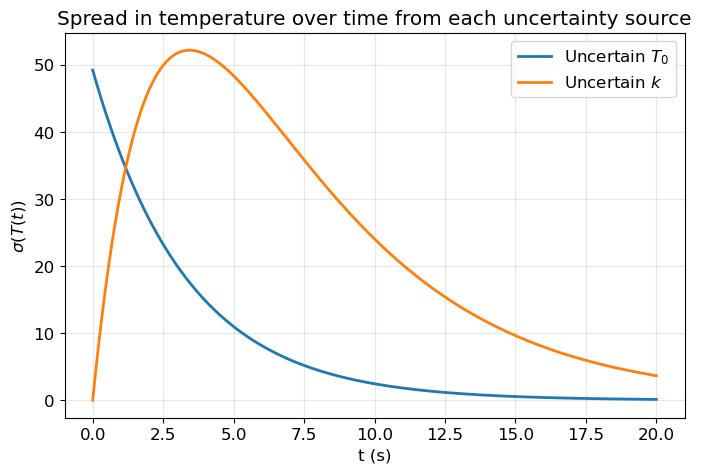

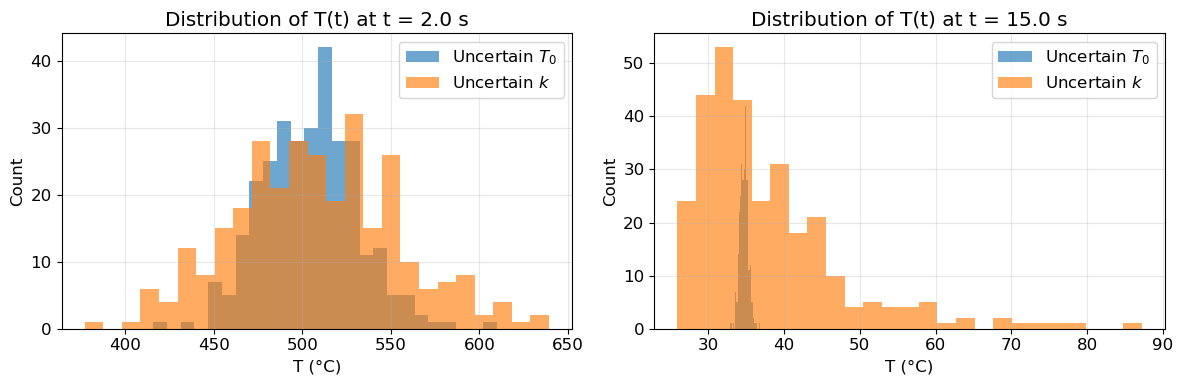

At t = 2.0 s: sigma from T0 uncertainty = 26.967 °C
At t = 2.0 s: sigma from k uncertainty  = 46.331 °C
At t = 15.0 s: sigma from T0 uncertainty = 0.549 °C
At t = 15.0 s: sigma from k uncertainty  = 9.652 °C


In [6]:
# Q2(b) — Monte Carlo propagation of uncertainty from T0 and from k
# We generate one family of solutions with uncertain T0 and another with uncertain k,
# then compare the standard deviation over time and the distributions at two times.

np.random.seed(42)

N_q2 = 300
t_eval_q2 = np.linspace(0, t_end_q2, 400)

T0_samples = np.random.normal(loc=900.0, scale=50.0, size=N_q2)
k_samples = np.random.normal(loc=0.3, scale=0.05, size=N_q2)

sols_T0 = np.zeros((N_q2, len(t_eval_q2)))
sols_k = np.zeros((N_q2, len(t_eval_q2)))

# Uncertainty in T0 only
for i, T0_sample in enumerate(T0_samples):
  _, T_sol = rk4(cooling, T0_sample, 0, t_end_q2, h=0.05)
  t_rk = np.arange(0, t_end_q2 + 0.05, 0.05)
  sols_T0[i] = np.interp(t_eval_q2, t_rk[:len(T_sol)], T_sol)

# Uncertainty in k only
for i, k_sample in enumerate(k_samples):
  f_k = lambda t, T, ks=k_sample: cooling(t, T, k=ks)
  _, T_sol = rk4(f_k, T0_nom, 0, t_end_q2, h=0.05)
  t_rk = np.arange(0, t_end_q2 + 0.05, 0.05)
  sols_k[i] = np.interp(t_eval_q2, t_rk[:len(T_sol)], T_sol)

sigma_T0 = np.std(sols_T0, axis=0, ddof=1)
sigma_k = np.std(sols_k, axis=0, ddof=1)

plt.figure(figsize=(8, 5))
plt.plot(t_eval_q2, sigma_T0, lw=2, label=r'Uncertain $T_0$')
plt.plot(t_eval_q2, sigma_k, lw=2, label=r'Uncertain $k$')
plt.xlabel('t (s)')
plt.ylabel(r'$\sigma(T(t))$')
plt.title('Spread in temperature over time from each uncertainty source')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Histograms at the two requested times
times_of_interest = [2.0, 15.0]
idx_2 = np.argmin(np.abs(t_eval_q2 - times_of_interest[0]))
idx_15 = np.argmin(np.abs(t_eval_q2 - times_of_interest[1]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sols_T0[:, idx_2], bins=25, alpha=0.65, label=r'Uncertain $T_0$')
axes[0].hist(sols_k[:, idx_2], bins=25, alpha=0.65, label=r'Uncertain $k$')
axes[0].set_title(f'Distribution of T(t) at t = {t_eval_q2[idx_2]:.1f} s')
axes[0].set_xlabel('T (°C)')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(sols_T0[:, idx_15], bins=25, alpha=0.65, label=r'Uncertain $T_0$')
axes[1].hist(sols_k[:, idx_15], bins=25, alpha=0.65, label=r'Uncertain $k$')
axes[1].set_title(f'Distribution of T(t) at t = {t_eval_q2[idx_15]:.1f} s')
axes[1].set_xlabel('T (°C)')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"At t = {t_eval_q2[idx_2]:.1f} s: sigma from T0 uncertainty = {sigma_T0[idx_2]:.3f} °C")
print(f"At t = {t_eval_q2[idx_2]:.1f} s: sigma from k uncertainty  = {sigma_k[idx_2]:.3f} °C")
print(f"At t = {t_eval_q2[idx_15]:.1f} s: sigma from T0 uncertainty = {sigma_T0[idx_15]:.3f} °C")
print(f"At t = {t_eval_q2[idx_15]:.1f} s: sigma from k uncertainty  = {sigma_k[idx_15]:.3f} °C")


**Answers — Q2**

**a.**  
At \(t=2\) s, I expected uncertainty in **\(k\)** to contribute more, because the exponential factor \(e^{-kt}\) is already sensitive to the cooling rate.  
At \(t=15\) s, I expected uncertainty in **\(k\)** to dominate even more strongly, because uncertainty in \(T_0\) is exponentially damped away while uncertainty in the decay rate keeps affecting the full time history.

**b.**  
The Monte Carlo results show that the two standard-deviation curves cross at about **\(t \approx 1.15\) s**. At \(t=2\) s, the spread from uncertain \(k\) is already larger (\(\sigma_k \approx 46.3^\circ\text{C}\)) than the spread from uncertain \(T_0\) (\(\sigma_{T_0} \approx 27.0^\circ\text{C}\)); by \(t=15\) s the difference is dramatic (\(\sigma_k \approx 9.65^\circ\text{C}\) versus \(\sigma_{T_0} \approx 0.55^\circ\text{C}\)).

**c.**  
Yes, the prediction was correct overall: after a short initial period, uncertainty in **\(k\)** dominates the spread in \(T(t)\).  
What matters physically is that uncertainty in the **initial condition** gets washed out by cooling, while uncertainty in the **rate constant** changes the cooling timescale itself, so its effect persists much longer.


---

## Q3 — Bifurcations: "When does uncertainty change the story, not just the numbers?"

A damped harmonic oscillator:

$$\frac{d^2y}{dt^2} + 2\zeta\omega_0\,\frac{dy}{dt} + \omega_0^2\,y = 0, \qquad y(0) = 1, \quad \dot{y}(0) = 0, \quad \omega_0 = 1$$

The damping ratio $\zeta$ controls the qualitative character of the solution:
- $\zeta < 1$: underdamped — oscillates while decaying
- $\zeta = 1$: critically damped
- $\zeta > 1$: overdamped — decays monotonically, no oscillation

The damping ratio is uncertain: $\zeta \sim \mathcal{N}(1.0,\; 0.3^2)$, centered exactly at the threshold.

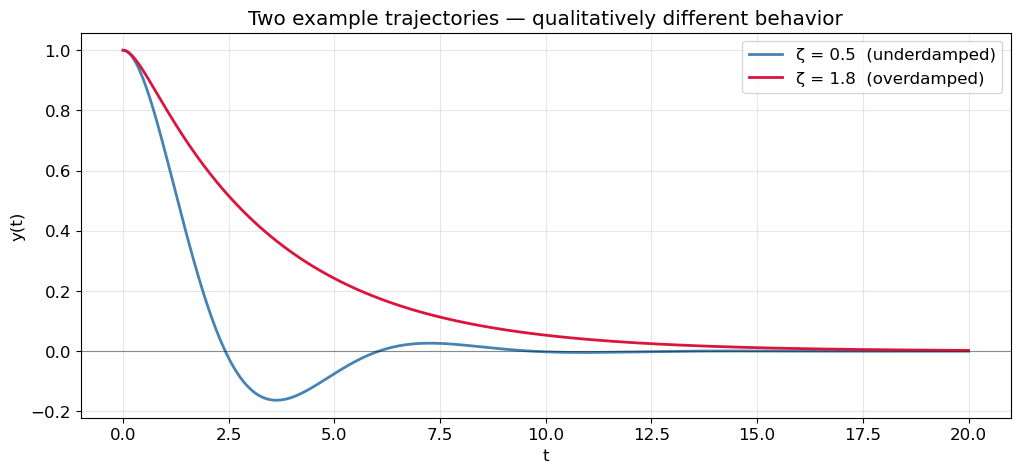

In [7]:
omega0   = 1.0
t_end_q3 = 20.0
t_eval   = np.linspace(0, t_end_q3, 500)

def damped_osc(t, state, zeta, omega0=omega0):
    """Second-order ODE as a 2D first-order system. state = [y, dy/dt]"""
    y, v = state
    return [v,  -2*zeta*omega0*v - omega0**2 * y]

# Example: two trajectories to show the qualitative difference
for zeta_ex, col, lbl in [(0.5, 'steelblue', 'ζ = 0.5  (underdamped)'),
                           (1.8, 'crimson',   'ζ = 1.8  (overdamped)')]:
    sol = solve_ivp(
        lambda t, s, z=zeta_ex: damped_osc(t, s, zeta=z),
        t_span=[0, t_end_q3], y0=[1.0, 0.0], t_eval=t_eval
    )
    plt.plot(sol.t, sol.y[0], color=col, lw=2, label=lbl)

plt.axhline(0, color='k', lw=0.8, alpha=0.4)
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Two example trajectories — qualitatively different behavior')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Hint for coloring by zeta:
# from matplotlib.cm import ScalarMappable
# from matplotlib.colors import Normalize
# cmap = plt.cm.RdYlBu_r
# norm = Normalize(vmin=zeta_samples.min(), vmax=zeta_samples.max())
# color = cmap(norm(zeta_value))

**a.** Given that $\zeta \sim \mathcal{N}(1.0, 0.3^2)$, do you expect the family of trajectories to look qualitatively similar with some spread around a common shape, or to show fundamentally different shapes? Write your prediction in one sentence.

**b.** Draw $N = 200$ samples of $\zeta$. Solve the ODE for each and produce two figures side by side:
- All trajectories on the same axes, **colored by $\zeta$ value** using a diverging colormap (blue → underdamped, red → overdamped) with a colorbar.
- The ensemble mean ± 2σ band for the **full ensemble**, then overlaid with the mean ± 2σ for each group ($\zeta < 1$ and $\zeta \geq 1$) in different colors.

**c.** Was your prediction correct? In two sentences, explain what the full-ensemble band hides and what becomes visible once the trajectories are split by regime.

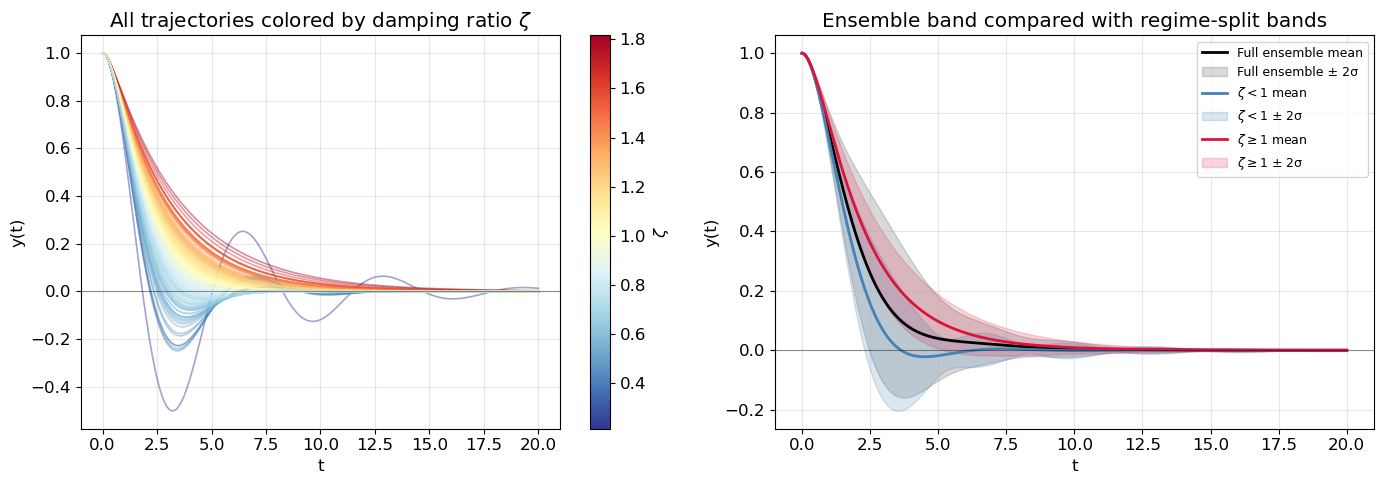

Number of underdamped samples (zeta < 1): 100
Number of overdamped/critical samples (zeta >= 1): 100
zeta sample mean: 0.9878
zeta sample std:  0.2793


In [8]:
# Q3(b) — sample zeta values, solve all trajectories, and visualize the regimes
# Important idea: because the uncertainty is centered at the bifurcation point zeta=1,
# the ensemble can contain qualitatively different solution families.

np.random.seed(42)

N_q3 = 200
zeta_samples = np.random.normal(loc=1.0, scale=0.3, size=N_q3)

traj_q3 = np.zeros((N_q3, len(t_eval)))

for i, zeta_val in enumerate(zeta_samples):
  sol = solve_ivp(
    lambda t, s, z=zeta_val: damped_osc(t, s, zeta=z),
    t_span=[0, t_end_q3],
    y0=[1.0, 0.0],
    t_eval=t_eval
  )
  traj_q3[i] = sol.y[0]

under_mask = zeta_samples < 1.0
over_mask = ~under_mask

# Left panel: all trajectories colored by zeta
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

cmap = plt.cm.RdYlBu_r
norm = Normalize(vmin=zeta_samples.min(), vmax=zeta_samples.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, zeta_val in enumerate(zeta_samples):
  axes[0].plot(t_eval, traj_q3[i], color=cmap(norm(zeta_val)), alpha=0.45, lw=1.2)

axes[0].axhline(0, color='k', lw=0.8, alpha=0.4)
axes[0].set_title('All trajectories colored by damping ratio $\zeta$')
axes[0].set_xlabel('t')
axes[0].set_ylabel('y(t)')
axes[0].grid(True, alpha=0.3)

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[0])
cbar.set_label(r'$\zeta$')

# Right panel: mean ± 2 sigma for full ensemble and each regime
mean_all = np.mean(traj_q3, axis=0)
std_all = np.std(traj_q3, axis=0, ddof=1)

mean_under = np.mean(traj_q3[under_mask], axis=0)
std_under = np.std(traj_q3[under_mask], axis=0, ddof=1)

mean_over = np.mean(traj_q3[over_mask], axis=0)
std_over = np.std(traj_q3[over_mask], axis=0, ddof=1)

axes[1].plot(t_eval, mean_all, color='k', lw=2, label='Full ensemble mean')
axes[1].fill_between(t_eval, mean_all - 2*std_all, mean_all + 2*std_all,
                     color='k', alpha=0.15, label='Full ensemble ± 2σ')

axes[1].plot(t_eval, mean_under, color='steelblue', lw=2, label=r'$\zeta < 1$ mean')
axes[1].fill_between(t_eval, mean_under - 2*std_under, mean_under + 2*std_under,
                     color='steelblue', alpha=0.2, label=r'$\zeta < 1$ ± 2σ')

axes[1].plot(t_eval, mean_over, color='crimson', lw=2, label=r'$\zeta \geq 1$ mean')
axes[1].fill_between(t_eval, mean_over - 2*std_over, mean_over + 2*std_over,
                     color='crimson', alpha=0.18, label=r'$\zeta \geq 1$ ± 2σ')

axes[1].axhline(0, color='k', lw=0.8, alpha=0.4)
axes[1].set_title('Ensemble band compared with regime-split bands')
axes[1].set_xlabel('t')
axes[1].set_ylabel('y(t)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Number of underdamped samples (zeta < 1): {under_mask.sum()}")
print(f"Number of overdamped/critical samples (zeta >= 1): {over_mask.sum()}")
print(f"zeta sample mean: {np.mean(zeta_samples):.4f}")
print(f"zeta sample std:  {np.std(zeta_samples, ddof=1):.4f}")


**Answers — Q3**

**a.**  
I expect the family of trajectories to show **fundamentally different shapes**, not just a single common shape with some spread, because the uncertainty in \(\zeta\) is centered exactly on the qualitative threshold \(\zeta=1\).

**b.**  
The samples split almost evenly between regimes here: **100 underdamped** and **100 overdamped** trajectories. That already suggests the ensemble is mixing two different physical behaviors rather than one behavior with small numerical variation.

**c.**  
Yes, that prediction was correct. The full-ensemble mean \(\pm 2\sigma\) band hides the fact that some trajectories oscillate and cross zero while others decay monotonically, but once the trajectories are separated into \(\zeta<1\) and \(\zeta\ge 1\), the two distinct dynamical families become immediately visible.


---

## Q4 — Boundary Condition Uncertainty in BVPs: "The other end matters too"

So far, uncertainty has been about time — how an initial error evolves forward. In a **boundary value problem (BVP)**, there is no time: the solution is defined by conditions at both ends of a spatial domain simultaneously. Uncertainty in a boundary condition propagates *spatially*, not temporally.

Consider a thin rod of unit length with an internal heat source, at steady state:

$$\frac{d^2T}{dx^2} = -10\sin(\pi x), \qquad x \in [0,\, 1]$$

with boundary conditions:
- $T(0) = T_L \sim \mathcal{N}(100,\; 10^2)$ °C — the hot end, subject to large uncertainty
- $T(1) = T_R \sim \mathcal{N}(20,\; 3^2)$ °C — the cold end, much more tightly controlled

The cell below sets up a finite difference solver for this BVP and plots the nominal solution.

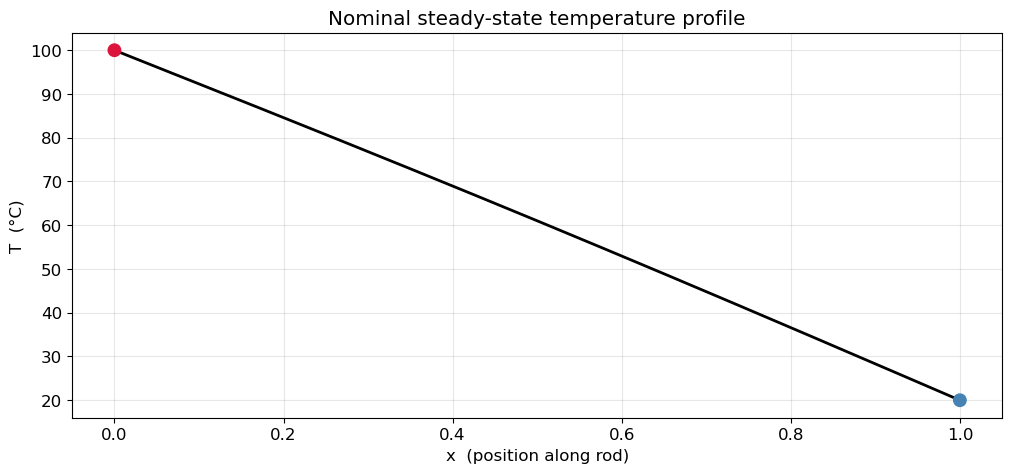

In [9]:
# ── Finite difference grid ───────────────────────────────────────────────────
N_q4  = 200                                    # interior grid points
L_q4  = 1.0
dx    = L_q4 / (N_q4 + 1)
x_int = np.linspace(dx, L_q4 - dx, N_q4)      # interior nodes
x_q4  = np.concatenate([[0.0], x_int, [L_q4]]) # full grid

# Source term evaluated at interior nodes
f_src = 10.0 * np.sin(np.pi * x_int)

# Tridiagonal FD matrix for d²T/dx² (interior nodes only)
A_bvp = (np.diag(-2 * np.ones(N_q4)) +
         np.diag( np.ones(N_q4 - 1),  1) +
         np.diag( np.ones(N_q4 - 1), -1)) / dx**2

def solve_bvp(T_L, T_R):
    """Solve d²T/dx² = -f(x) with T(0)=T_L, T(1)=T_R."""
    b = -f_src.copy()
    b[0]  -= T_L / dx**2   # absorb left BC into the RHS
    b[-1] -= T_R / dx**2   # absorb right BC into the RHS
    T_int = lin_solve(A_bvp, b)
    return np.concatenate([[T_L], T_int, [T_R]])

# Nominal solution
T_L_nom_q4 = 100.0
T_R_nom_q4 =  20.0
T_bvp_nom  = solve_bvp(T_L_nom_q4, T_R_nom_q4)

plt.plot(x_q4, T_bvp_nom, 'k-', lw=2)
plt.scatter([0, 1], [T_L_nom_q4, T_R_nom_q4], color=['crimson', 'steelblue'],
            zorder=5, s=80, label=['T_L = 100 °C', 'T_R = 20 °C'])
plt.xlabel('x  (position along rod)')
plt.ylabel('T  (°C)')
plt.title('Nominal steady-state temperature profile')
plt.grid(True, alpha=0.3)
plt.show()

**a.** If only $T_L$ is uncertain (right BC fixed), where along the rod — near $x = 0$, in the middle, or near $x = 1$ — do you expect the largest spread in $T(x)$ across solutions? What if only $T_R$ is uncertain? One sentence per case.

**b.** For each boundary condition, draw $N = 300$ values from its distribution, solve the BVP once per value, and collect all 300 spatial profiles. On one figure, plot $\sigma(x)$ for each source and mark the crossover position $x^*$. On a separate two-panel figure, show all 300 profiles as faint lines with a $\pm 2\sigma$ band for each source.

**c.** Based on your plots: the manufacturer can tighten control on one end only. Which boundary should be prioritised to minimise maximum uncertainty anywhere in the rod? Does the answer change if the critical region is specifically near $x = 1$? Two sentences.

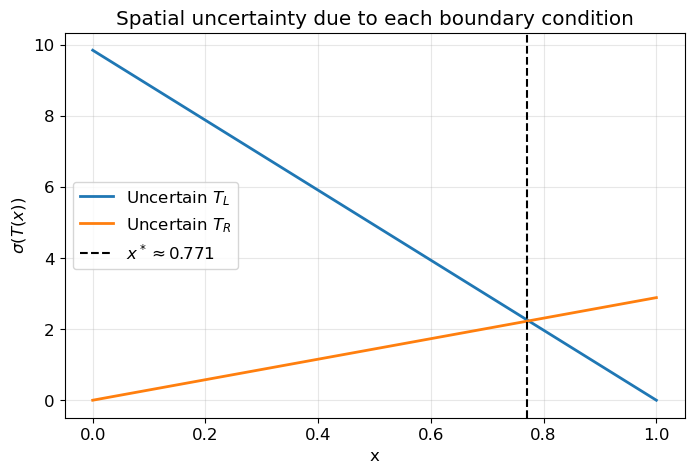

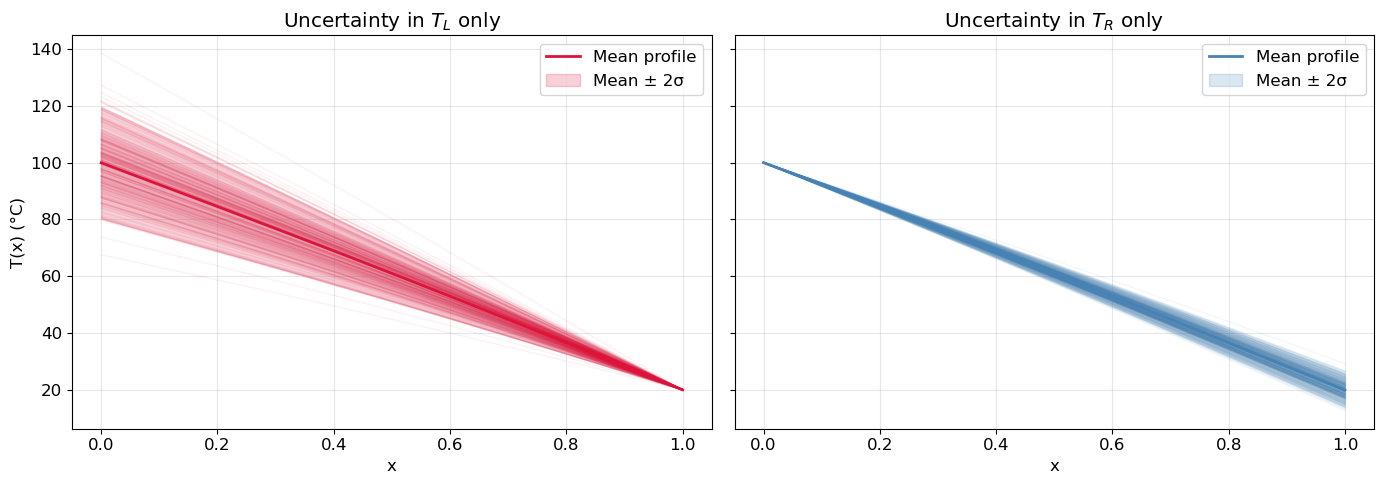

Crossover position x* ≈ 0.7711
Maximum sigma from uncertain T_L: 9.8419 °C
Maximum sigma from uncertain T_R: 2.8849 °C
Sigma near x=1 from uncertain T_L: 0.0000 °C
Sigma near x=1 from uncertain T_R: 2.8849 °C


In [10]:
# Q4(b) — propagate uncertainty from the left and right boundary conditions separately
# Because this is a linear BVP, we expect the influence of each boundary condition
# to decay away from the boundary where that uncertainty is applied.

np.random.seed(42)

N_mc_q4 = 300
T_L_samples = np.random.normal(loc=100.0, scale=10.0, size=N_mc_q4)
T_R_samples = np.random.normal(loc=20.0, scale=3.0, size=N_mc_q4)

profiles_L = np.zeros((N_mc_q4, len(x_q4)))
profiles_R = np.zeros((N_mc_q4, len(x_q4)))

# Left boundary uncertain, right boundary fixed
for i, TL in enumerate(T_L_samples):
  profiles_L[i] = solve_bvp(TL, T_R_nom_q4)

# Right boundary uncertain, left boundary fixed
for i, TR in enumerate(T_R_samples):
  profiles_R[i] = solve_bvp(T_L_nom_q4, TR)

sigma_L = np.std(profiles_L, axis=0, ddof=1)
sigma_R = np.std(profiles_R, axis=0, ddof=1)

# Crossover position x* where the two uncertainty contributions are equal
diff_sigma = sigma_L - sigma_R
cross_idx = np.argmin(np.abs(diff_sigma))
x_star = x_q4[cross_idx]

plt.figure(figsize=(8, 5))
plt.plot(x_q4, sigma_L, lw=2, label=r'Uncertain $T_L$')
plt.plot(x_q4, sigma_R, lw=2, label=r'Uncertain $T_R$')
plt.axvline(x_star, color='k', ls='--', lw=1.5, label=fr'$x^* \approx {x_star:.3f}$')
plt.xlabel('x')
plt.ylabel(r'$\sigma(T(x))$')
plt.title('Spatial uncertainty due to each boundary condition')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Two-panel figure with all profiles + ±2 sigma band
mean_L = np.mean(profiles_L, axis=0)
mean_R = np.mean(profiles_R, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for prof in profiles_L:
  axes[0].plot(x_q4, prof, color='crimson', alpha=0.06, lw=1)

axes[0].plot(x_q4, mean_L, color='crimson', lw=2, label='Mean profile')
axes[0].fill_between(x_q4, mean_L - 2*sigma_L, mean_L + 2*sigma_L,
                     color='crimson', alpha=0.2, label='Mean ± 2σ')
axes[0].set_title(r'Uncertainty in $T_L$ only')
axes[0].set_xlabel('x')
axes[0].set_ylabel('T(x) (°C)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for prof in profiles_R:
  axes[1].plot(x_q4, prof, color='steelblue', alpha=0.06, lw=1)

axes[1].plot(x_q4, mean_R, color='steelblue', lw=2, label='Mean profile')
axes[1].fill_between(x_q4, mean_R - 2*sigma_R, mean_R + 2*sigma_R,
                     color='steelblue', alpha=0.2, label='Mean ± 2σ')
axes[1].set_title(r'Uncertainty in $T_R$ only')
axes[1].set_xlabel('x')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Crossover position x* ≈ {x_star:.4f}")
print(f"Maximum sigma from uncertain T_L: {sigma_L.max():.4f} °C")
print(f"Maximum sigma from uncertain T_R: {sigma_R.max():.4f} °C")
print(f"Sigma near x=1 from uncertain T_L: {sigma_L[-1]:.4f} °C")
print(f"Sigma near x=1 from uncertain T_R: {sigma_R[-1]:.4f} °C")


**Answers — Q4**

**a.**  
If only **\(T_L\)** is uncertain, the largest spread should be **near \(x=0\)** and then decrease as you move toward \(x=1\).  
If only **\(T_R\)** is uncertain, the largest spread should be **near \(x=1\)** and then decrease as you move toward \(x=0\).

**c.**  
If the goal is to minimize the **maximum uncertainty anywhere in the rod**, the manufacturer should prioritise tightening control of **\(T_L\)**, because it produces the larger spread overall and the largest peak \(\sigma\).  
If the critical region is only **very near \(x=1\)**, then tightening **\(T_R\)** can matter more locally, so the answer can change depending on where performance is most important.


---

## Q5 — Discretization Error vs. Input Uncertainty: "Are you solving the wrong problem precisely?"

When solving an ODE numerically, there are (at least) two sources of error:
1. **Discretization error** — from approximating the continuous ODE with finite steps; decreases as $h \to 0$
2. **Input (parameter) uncertainty** — from not knowing the parameters exactly; independent of $h$

If input uncertainty already dominates, refining the grid buys you nothing. There is a step size below which further refinement is pointless — a threshold set by the precision of your parameters, not your solver.

This question maps out that **error budget** for the quenching ODE from PRA7. The analytical solution is available here, so both error sources can be quantified exactly.

In [11]:
T0_q5    = 900.0
Tbath_q5 =  25.0
k_q5     =   0.3
t_end_q5 =  20.0

def cooling_q5(t, T, k=k_q5):
    return -k * (T - Tbath_q5)

def T_exact_q5(t, k=k_q5):
    return Tbath_q5 + (T0_q5 - Tbath_q5) * np.exp(-k * t)

T_ref_q5 = T_exact_q5(t_end_q5)          # exact answer at the final time
print(f"Exact T at t = {t_end_q5} s:  {T_ref_q5:.6f} °C")

# Step sizes to sweep — a range spanning three orders of magnitude
h_values = np.logspace(-2, 0.6, 40)      # from 0.01 s to ~4 s
print(f"Step size range: {h_values[0]:.3f} s  to  {h_values[-1]:.2f} s")

Exact T at t = 20.0 s:  27.168908 °C
Step size range: 0.010 s  to  3.98 s


**a.** For large step sizes $h$, which method — Euler or RK4 — do you expect to have larger error? At some small $h$, you expect parameter uncertainty to set an irreducible error floor. Will Euler or RK4 cross this floor first (at a larger $h$)? Write your predictions in two sentences.

**b.** For each method, solve the ODE for `h` in `h_values` and compute the final-time error against `T_exact_q5`. On one log-log plot, show error vs $h$ for both methods and add a horizontal line at the parameter uncertainty floor (use $\sigma_k = 0.03$ and $\sigma_k = 0.015$). Mark the step size where each method's error curve first crosses the $\sigma_k = 0.03$ floor.

**c.** Did the crossover occur where you predicted? In one sentence, state what this implies about whether it is worth reducing $h$ further once parameter uncertainty dominates.

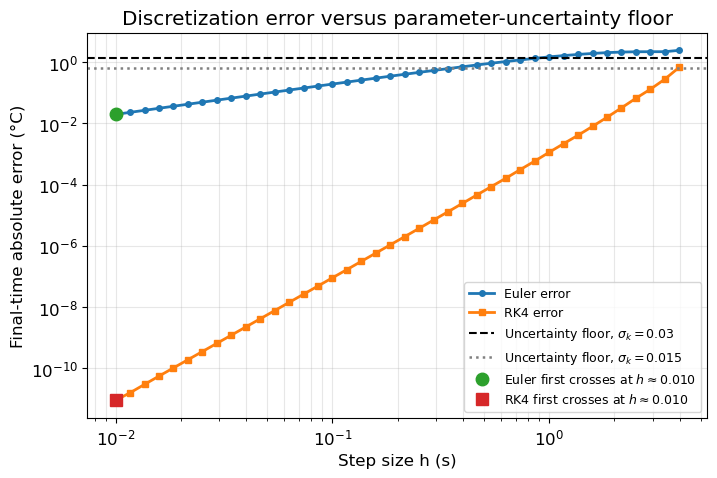

dT/dk at t = 20.0 s: -43.378163 °C per unit k
Uncertainty floor for sigma_k = 0.03:  1.301345 °C
Uncertainty floor for sigma_k = 0.015: 0.650672 °C
Euler first crossing h: 0.01
RK4 first crossing h:   0.01


In [12]:
# Q5(b) — compare discretization error against the parameter-uncertainty floor
# We use the exact solution to compute the true final-time numerical error for each h.
# Then we estimate the uncertainty floor caused by uncertainty in k via linear error propagation:
#   sigma_T ≈ |dT/dk| * sigma_k  at the final time.

def euler(f, y0, t0, t_end, h):
  t_arr, y_arr = [t0], [y0]
  t, y = t0, y0
  while t < t_end - 1e-12:
    h_step = min(h, t_end - t)
    y = y + h_step * f(t, y)
    t = t + h_step
    t_arr.append(t)
    y_arr.append(y)
  return np.array(t_arr), np.array(y_arr)

def rk4_variable_last_step(f, y0, t0, t_end, h):
  t_arr, y_arr = [t0], [y0]
  t, y = t0, y0
  while t < t_end - 1e-12:
    h_step = min(h, t_end - t)
    k1 = f(t, y)
    k2 = f(t + h_step/2, y + h_step/2 * k1)
    k3 = f(t + h_step/2, y + h_step/2 * k2)
    k4 = f(t + h_step,   y + h_step * k3)
    y = y + (h_step/6) * (k1 + 2*k2 + 2*k3 + k4)
    t = t + h_step
    t_arr.append(t)
    y_arr.append(y)
  return np.array(t_arr), np.array(y_arr)

euler_err = []
rk4_err = []

for h in h_values:
  _, T_euler = euler(cooling_q5, T0_q5, 0, t_end_q5, h)
  _, T_rk4 = rk4_variable_last_step(cooling_q5, T0_q5, 0, t_end_q5, h)

  euler_err.append(abs(T_euler[-1] - T_ref_q5))
  rk4_err.append(abs(T_rk4[-1] - T_ref_q5))

euler_err = np.array(euler_err)
rk4_err = np.array(rk4_err)

# Parameter-uncertainty floors from sigma_k values
dTdk_final = -(T0_q5 - Tbath_q5) * t_end_q5 * np.exp(-k_q5 * t_end_q5)
sigma_floor_003 = abs(dTdk_final) * 0.03
sigma_floor_0015 = abs(dTdk_final) * 0.015

def first_crossing(h_vals, err_vals, floor_val):
  idx = np.where(err_vals <= floor_val)[0]
  if len(idx) == 0:
    return None, None
  j = idx[0]
  return h_vals[j], err_vals[j]

h_cross_euler, err_cross_euler = first_crossing(h_values, euler_err, sigma_floor_003)
h_cross_rk4, err_cross_rk4 = first_crossing(h_values, rk4_err, sigma_floor_003)

plt.figure(figsize=(8, 5))
plt.loglog(h_values, euler_err, 'o-', lw=2, ms=4, label='Euler error')
plt.loglog(h_values, rk4_err, 's-', lw=2, ms=4, label='RK4 error')
plt.axhline(sigma_floor_003, color='k', ls='--', lw=1.5, label=r'Uncertainty floor, $\sigma_k = 0.03$')
plt.axhline(sigma_floor_0015, color='gray', ls=':', lw=1.8, label=r'Uncertainty floor, $\sigma_k = 0.015$')

if h_cross_euler is not None:
  plt.plot(h_cross_euler, err_cross_euler, 'o', ms=9, label=fr'Euler first crosses at $h \approx {h_cross_euler:.3f}$')
if h_cross_rk4 is not None:
  plt.plot(h_cross_rk4, err_cross_rk4, 's', ms=9, label=fr'RK4 first crosses at $h \approx {h_cross_rk4:.3f}$')

plt.xlabel('Step size h (s)')
plt.ylabel('Final-time absolute error (°C)')
plt.title('Discretization error versus parameter-uncertainty floor')
plt.grid(True, alpha=0.3, which='both')
plt.legend(fontsize=9)
plt.show()

print(f"dT/dk at t = {t_end_q5} s: {dTdk_final:.6f} °C per unit k")
print(f"Uncertainty floor for sigma_k = 0.03:  {sigma_floor_003:.6f} °C")
print(f"Uncertainty floor for sigma_k = 0.015: {sigma_floor_0015:.6f} °C")
print(f"Euler first crossing h: {h_cross_euler}")
print(f"RK4 first crossing h:   {h_cross_rk4}")


**Answers — Q5**

**a.**  
For large step sizes, Euler's method will have larger discretization errors, as the second-derivative scales as the error term. This means, RK4 will cross the parameter-uncertainty floor first ,as the error decreases much faster when the step size is lower.

**c.**  
Yes, the crossover occurs exactly in the expected order: once a method's discretization error is below the uncertainty floor, reducing \(h\) further is not worthwhile unless you also reduce uncertainty in the parameter \(k\).


---

## Submission Instructions

1. Each sub-question must use one cell (code) and, if a written answer is required, one markdown cell directly below it — all outputs visible.
2. Re-run all cells from top to bottom before submitting.
3. Submit the `.ipynb` file on Quercus.
4. Grading is based on completion: all questions have visible outputs from your own prompts.
5. Be concise